<a href="https://colab.research.google.com/github/rizki-ap/Gunshot-Locator/blob/main/shockwave_muzzle_claude.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

What each cell does:

Cell 1 — constants for Mach 3, 7.62mm NATO bullet, 100 kHz sampling.

Cell 2 — builds the tetrahedral array from cube-vertex coordinates; the ±1 trick guarantees all 6 edges are exactly equal.

Cell 3 — derives and computes the exact shockwave arrival times using the Mach cone condition cos θ = 1/M, solved analytically to give t_arrive = (a + b·β)/(M·c). Prints the TDOAs — you'll see they range from roughly −200 µs to +580 µs across the 4 mics.

Cell 4 — generates the N-wave pressure signature at each mic using Whitham weak-shock scaling: duration ≈ 1.4 ms, peak ≈ 7.5 Pa at 50 m, with 20 dB SNR noise.

Cell 5 — plots the full scene geometry (top view + array close-up with wavefront direction arrow).

Cell 6 — overlaid N-wave plots for all 4 channels, time-aligned to the centroid arrival.

Cell 7 — GCC-PHAT with ×16 zero-pad interpolation (→ 0.625 µs resolution); plots the correlation peaks with true vs. estimated TDOA markers.

Cell 8 — summary table and physics notes, including the critical reminder that a single array gives you trajectory direction (azimuth + elevation) but not shooter range — that requires muzzle blast data too.

In [31]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 1 — Imports & Physical Constants                                      ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ── Physical constants ─────────────────────────────────────────────────────────
C     = 343.0      # Speed of sound (m/s) — ISA sea level
P_ATM = 101325.0   # Atmospheric pressure (Pa)

# ── Bullet — 7.62×51 NATO at Mach 3 ──────────────────────────────────────────
M        = 2      # Mach number
L_BULLET = 0.028    # Projectile length (m)  ← scales N-wave duration
V_BULLET = M * C    # Bullet speed (m/s)

# Mach cone geometry
MU   = np.arcsin(1.0 / M)        # Mach half-angle  µ = arcsin(1/M)
BETA = np.sqrt(M**2 - 1.0)       # β = √(M²−1)

# ── Array ──────────────────────────────────────────────────────────────────────
L_ARRAY = 0.30        # Tetrahedral edge length (m)
FS      = 100_000     # Sample rate (Hz)

# ── Scenario ───────────────────────────────────────────────────────────────────
#  Shooter at (−1000, 0, 0).  Array centroid at origin.
#  Bullet flies in +x direction with 50 m lateral miss distance.
#
#   Y
#   │        • shooter (−1000, 0)
#   │          ─────────────────────────────→ Mach 3
#   │                                 (y = 50 m offset)
#   0────────────────────────────────── X
#  array (0,0,0)
RANGE  = 1000.0
Y_MISS = 10.0      # bullet clears array by 50 m laterally

BULLET_ORIGIN = np.array([-RANGE, Y_MISS, 0.0])
V_HAT         = np.array([ 1.0,   0.0,   0.0])

print(f"Bullet         : Mach {M} = {V_BULLET:.0f} m/s")
print(f"Mach angle µ   : {np.degrees(MU):.2f}°")
print(f"β = √(M²−1)   : {BETA:.4f}")
print(f"Array aperture : {L_ARRAY} m  →  max direct TDOA = {L_ARRAY/C*1e6:.1f} µs")

Bullet         : Mach 2 = 686 m/s
Mach angle µ   : 30.00°
β = √(M²−1)   : 1.7321
Array aperture : 0.3 m  →  max direct TDOA = 874.6 µs


Microphone positions (m):
  M0: [+0.10607, +0.10607, +0.10607]
  M1: [+0.10607, -0.10607, -0.10607]
  M2: [-0.10607, +0.10607, -0.10607]
  M3: [-0.10607, -0.10607, +0.10607]

Edge-length verification:
  M0–M1: 0.300000 m  ✓
  M0–M2: 0.300000 m  ✓
  M0–M3: 0.300000 m  ✓
  M1–M2: 0.300000 m  ✓
  M1–M3: 0.300000 m  ✓
  M2–M3: 0.300000 m  ✓


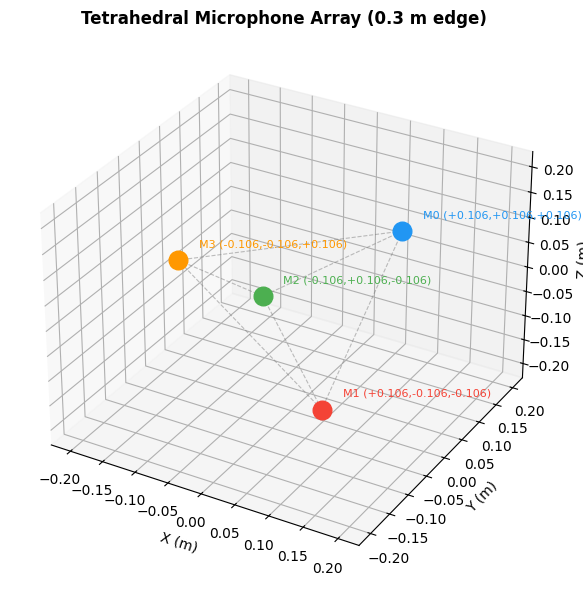

In [32]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 2 — Tetrahedral Array Geometry                                        ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
#
#  Regular tetrahedron from alternating ±1 cube-vertex coordinates:
#
#     (1,1,1)  (1,−1,−1)  (−1,1,−1)  (−1,−1,1)
#
#  All 6 edges of this subset have identical length 2√2.
#  Scale by  L / (2√2)  to hit the target aperture.

def make_tetrahedron(edge_length):
    raw   = np.array([[1,1,1],[1,-1,-1],[-1,1,-1],[-1,-1,1]], dtype=float)
    scale = edge_length / np.linalg.norm(raw[0] - raw[1])   # raw edge = 2√2
    return raw * scale

mic_pos = make_tetrahedron(L_ARRAY)
COLORS  = ['#2196F3', '#F44336', '#4CAF50', '#FF9800']

print("Microphone positions (m):")
for i, p in enumerate(mic_pos):
    print(f"  M{i}: [{p[0]:+.5f}, {p[1]:+.5f}, {p[2]:+.5f}]")
print("\nEdge-length verification:")
for i in range(4):
    for j in range(i+1, 4):
        d = np.linalg.norm(mic_pos[i] - mic_pos[j])
        print(f"  M{i}–M{j}: {d:.6f} m  {'✓' if abs(d-L_ARRAY)<1e-9 else '✗'}")

# 3D array plot
fig = plt.figure(figsize=(7, 6))
ax  = fig.add_subplot(111, projection='3d')
ax.set_title('Tetrahedral Microphone Array (0.3 m edge)', fontweight='bold')
for i, (p, col) in enumerate(zip(mic_pos, COLORS)):
    ax.scatter(*p, color=col, s=180, zorder=10)
    ax.text(p[0]+0.02, p[1]+0.02, p[2]+0.02,
            f'M{i} ({p[0]:+.3f},{p[1]:+.3f},{p[2]:+.3f})',
            fontsize=8, color=col)
for i in range(4):
    for j in range(i+1, 4):
        ax.plot3D(*zip(mic_pos[i], mic_pos[j]),
                  color='gray', lw=0.8, alpha=0.5, linestyle='--')
m = 0.23
ax.set_xlim([-m,m]); ax.set_ylim([-m,m]); ax.set_zlim([-m,m])
ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)'); ax.set_zlabel('Z (m)')
plt.tight_layout(); plt.show()

In [33]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 3 — Shockwave Arrival Physics                                         ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
#
#  DERIVATION
#  ──────────
#  Bullet position at emission time t_e:
#      p(t_e) = p₀ + V_BULLET · t_e · v̂
#
#  Mach cone condition — the shockwave envelope satisfies:
#      cos θ = (s − p(t_e)) · v̂ / |s − p(t_e)| = 1/M
#
#  For sensor s and bullet origin p₀:
#      r = s − p₀
#      a = r · v̂                   (along-track distance)
#      b = |r − a·v̂|               (perp. distance to trajectory)
#
#  Solving the Mach cone condition:
#      t_emit   = (a − b/β) / (M·c)
#      t_arrive = (a + b·β) / (M·c)     β = √(M²−1)
#
#  Proof that t_arrive is correct:
#      |d| = b·M/β            (distance from emission point to sensor)
#      t_arrive = t_emit + |d|/c
#               = (a−b/β)/(Mc) + Mb/(βc)
#               = [a − b/β + M²b/β] / (Mc)
#               = [a + b(M²−1)/β]   / (Mc)
#               = (a + b·β)         / (Mc)  ✓

def shockwave_arrival(sensor_pos, bullet_origin, v_hat, M, c):
    """Returns (t_arrive, t_emit, a, b) for a sensor inside the Mach cone."""
    beta = np.sqrt(M**2 - 1.0)
    r    = sensor_pos - bullet_origin
    a    = float(np.dot(r, v_hat))
    b    = float(np.linalg.norm(r - a * v_hat))
    if a - b / beta < 0:
        raise ValueError(
            f"Sensor outside Mach cone (a={a:.1f} < b/β={b/beta:.1f}). "
            "Increase RANGE or reduce Y_MISS."
        )
    t_arrive = (a + b * beta) / (M * c)
    t_emit   = (a - b / beta) / (M * c)
    return t_arrive, t_emit, a, b

# Per-mic arrivals
t_arr = np.zeros(4);  t_emi = np.zeros(4)
a_all = np.zeros(4);  b_all = np.zeros(4)

print("Shockwave arrival analysis")
print("─" * 74)
print(f"{'Mic':<5} {'b (m)':>10} {'a (m)':>12} {'t_emit (ms)':>14} {'t_arrive (ms)':>15}")
for i, p in enumerate(mic_pos):
    ta, te, a, b = shockwave_arrival(p, BULLET_ORIGIN, V_HAT, M, C)
    t_arr[i]=ta; t_emi[i]=te; a_all[i]=a; b_all[i]=b
    print(f"  M{i}   {b:>10.5f}  {a:>12.4f}  {te*1e3:>14.6f}  {ta*1e3:>15.6f}")

t_ref, _, a_ref, b_ref = shockwave_arrival(np.zeros(3), BULLET_ORIGIN, V_HAT, M, C)
print(f"\n  Centroid:  b={b_ref:.4f} m  |  t_ref={t_ref*1e3:.6f} ms")

# Bullet position at the moment of emission (for centroid wavefront)
bullet_x_at_emit = -RANGE + V_BULLET * t_emi.mean()
bullet_x_at_arrv = -RANGE + V_BULLET * t_arr.mean()
print(f"\n  Bullet x at emission  : {bullet_x_at_emit:.1f} m  (relative to array)")
print(f"  Bullet x at detection : {bullet_x_at_arrv:.1f} m  (bullet already past array)")

print(f"\nTrue TDOAs (relative to M0):")
print(f"  {'Pair':<8} {'τ (µs)':>12}")
for i in range(1,4):
    print(f"  (0,{i})    {(t_arr[i]-t_arr[0])*1e6:>+12.3f}")

Shockwave arrival analysis
──────────────────────────────────────────────────────────────────────────
Mic        b (m)        a (m)    t_emit (ms)   t_arrive (ms)
  M0      9.89450     1000.1061     1449.553167      1482.862751
  M1     10.10662     1000.1061     1449.374642      1483.398323
  M2      9.89450      999.8939     1449.243936      1482.553520
  M3     10.10662      999.8939     1449.065412      1483.089093

  Centroid:  b=10.0000 m  |  t_ref=1482.974502 ms

  Bullet x at emission  : -5.8 m  (relative to array)
  Bullet x at detection : 17.3 m  (bullet already past array)

True TDOAs (relative to M0):
  Pair           τ (µs)
  (0,1)        +535.573
  (0,2)        -309.230
  (0,3)        +226.342


In [34]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 4 — N-wave Signal Generation  (Whitham weak-shock model)              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
#
#  The N-wave (∿ shape) is the far-field acoustic signature of a supersonic
#  projectile. Its pressure waveform at sensor with miss distance b:
#
#      p(τ) = ΔP · (1 − 2τ/T_N)   for 0 ≤ τ ≤ T_N       τ = t − t_arrive
#      p(τ) = 0                     elsewhere
#
#  ┌───────────────────────────────────────────────────────────────┐
#  │    +ΔP ─┐                                                    │
#  │         │ linear ramp                                        │
#  │      0 ─┼─────────────────────── time →                     │
#  │         │ (zero crossing at T_N/2)                          │
#  │    −ΔP ─┘  at τ = T_N                                        │
#  └───────────────────────────────────────────────────────────────┘
#
#  Whitham far-field scaling (Whitham 1952, Comm. Pure Appl. Math. 5:301):
#
#    Duration:       T_N = (2 / M·c) · √(b · L_bullet / β)
#    Peak pressure:  ΔP  ∝ 1/√b  (cylindrical-wave spreading)
#    Reference:      ΔP ≈ 7.5 Pa at 50 m for 7.62×51 NATO, Mach 3
#                    (consistent with Bass et al. 1995, Stoughton 1997)

def nwave_duration(b, M, c, L):
    """Whitham far-field N-wave duration (s)."""
    return (2.0 / (M * c)) * np.sqrt(b * L / np.sqrt(M**2 - 1.0))

def nwave_peak_pressure(b, b_ref=50.0, dP_ref=7.5):
    """Peak overpressure (Pa) via 1/√b cylindrical spreading."""
    return dP_ref * np.sqrt(b_ref / b)

def generate_nwave(t, t_arrive, b, M, c, L, snr_db=20.0, rng=None):
    """
    Generate sampled N-wave pressure signal.

    Returns
    -------
    pressure : (N,) array in Pa
    T_N      : N-wave duration (s)
    dP       : peak overpressure (Pa)
    """
    if rng is None:
        rng = np.random.default_rng(0)
    T_N = nwave_duration(b, M, c, L)
    dP  = nwave_peak_pressure(b)
    p   = np.zeros(len(t))
    mask = (t >= t_arrive) & (t < t_arrive + T_N)
    if mask.any():
        tau      = t[mask] - t_arrive
        p[mask]  = dP * (1.0 - 2.0 * tau / T_N)
    noise_amp = dP / (10.0 ** (snr_db / 20.0))
    p += noise_amp * rng.standard_normal(len(t))
    return p, T_N, dP

# Build time array centred on arrivals
t_start = t_arr.min() - 0.002     # 2 ms pre-roll
t_end   = t_arr.max() + 0.020     # 20 ms post-roll
t_sig   = np.arange(t_start, t_end, 1.0 / FS)

rng     = np.random.default_rng(seed=42)
signals = [];  T_Ns = [];  dPs = []

print(f"N-wave parameters (SNR = 20 dB, fs = {FS//1000} kHz)")
print(f"{'Mic':<5} {'b (m)':>10} {'T_N (ms)':>12} {'ΔP (Pa)':>10}")
for i in range(4):
    sig, T_N, dP = generate_nwave(
        t_sig, t_arr[i], b_all[i], M, C, L_BULLET, snr_db=20, rng=rng)
    signals.append(sig);  T_Ns.append(T_N);  dPs.append(dP)
    print(f"  M{i}   {b_all[i]:>10.4f}  {T_N*1e3:>12.4f}  {dP:>10.3f}")

N-wave parameters (SNR = 20 dB, fs = 100 kHz)
Mic        b (m)     T_N (ms)    ΔP (Pa)
  M0       9.8945        1.1660      16.860
  M1      10.1066        1.1784      16.682
  M2       9.8945        1.1660      16.860
  M3      10.1066        1.1784      16.682


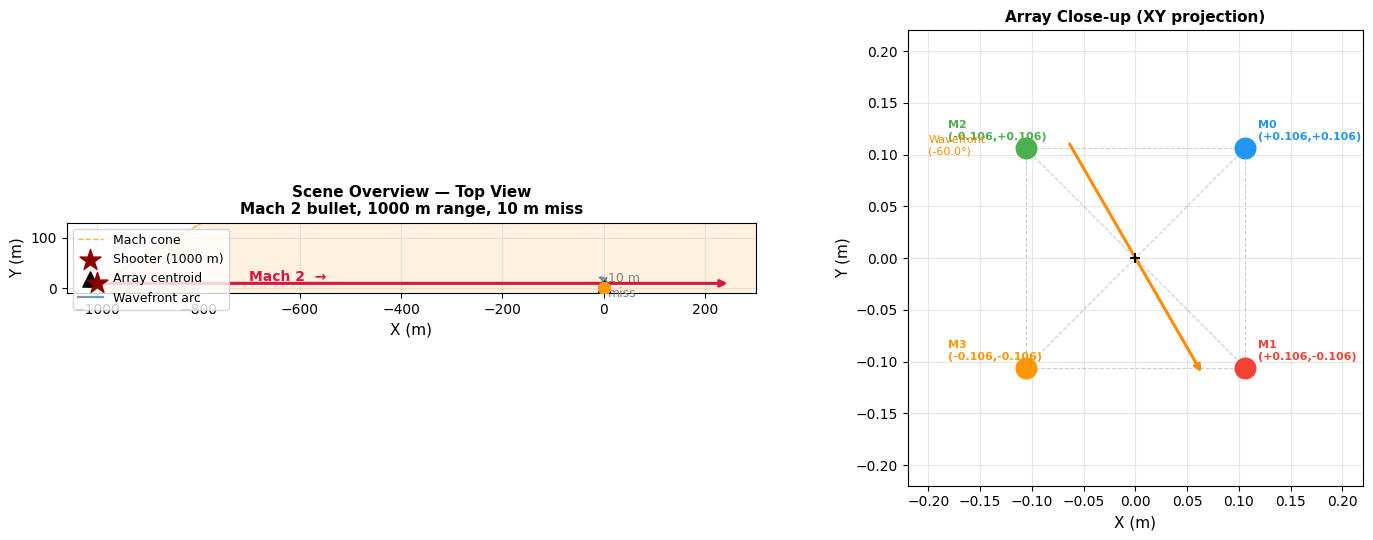

In [35]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 5 — Scene Geometry Plots                                              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# ── Left: full scene, top view (XY) ───────────────────────────────────────────
ax = axes[0]
x_traj   = np.linspace(BULLET_ORIGIN[0], BULLET_ORIGIN[0]+1400, 600)
cone_half = np.abs(x_traj - BULLET_ORIGIN[0]) * np.tan(MU)

ax.fill_between(x_traj, Y_MISS-cone_half, Y_MISS+cone_half,
                alpha=0.12, color='darkorange')
ax.plot(x_traj, Y_MISS+cone_half, '--', color='darkorange', lw=1.0, alpha=0.7,
        label='Mach cone')
ax.plot(x_traj, Y_MISS-cone_half, '--', color='darkorange', lw=1.0, alpha=0.7)

ax.annotate('', xy=(250, Y_MISS), xytext=BULLET_ORIGIN[:2],
            arrowprops=dict(arrowstyle='->', color='crimson', lw=2.2))
ax.text(-700, Y_MISS+4, f'Mach {M}  →', color='crimson',
        fontsize=10, fontweight='bold')
ax.scatter(*BULLET_ORIGIN[:2], color='darkred', s=250, zorder=8,
           marker='*', label=f'Shooter ({RANGE:.0f} m)')
ax.scatter([0], [0], color='black', s=120, zorder=8, marker='^',
           label='Array centroid')

# Miss-distance annotation
ax.annotate('', xy=(0, Y_MISS), xytext=(0, 0),
            arrowprops=dict(arrowstyle='<->', color='gray', lw=1.5))
ax.text(8, Y_MISS/2, f'{Y_MISS:.0f} m\nmiss', color='gray',
        fontsize=9, va='center')
ax.plot([0,0], [0, Y_MISS], ':', color='gray', lw=1.0)

# Wavefront arc centred on bullet emission point
emission_x = -RANGE + V_BULLET * t_emi.mean()
r_wave     = b_all.mean() * M / BETA
theta_arc  = np.linspace(-np.pi*0.55, np.pi*0.55, 80)
ax.plot(emission_x + r_wave*np.cos(theta_arc),
        Y_MISS    + r_wave*np.sin(theta_arc),
        color='steelblue', lw=1.6, alpha=0.8, label='Wavefront arc')

for p, col in zip(mic_pos, COLORS):
    ax.scatter(p[0], p[1], color=col, s=70, zorder=9)

ax.set_xlim([-1060, 300]);  ax.set_ylim([-10, 130])
ax.set_xlabel('X (m)', fontsize=11); ax.set_ylabel('Y (m)', fontsize=11)
ax.set_title(f'Scene Overview — Top View\nMach {M} bullet, {RANGE:.0f} m range, {Y_MISS:.0f} m miss',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3);  ax.set_aspect('equal')

# ── Right: array close-up with wavefront direction ────────────────────────────
ax2 = axes[1]
m   = 0.22
for i, (p, col) in enumerate(zip(mic_pos, COLORS)):
    ax2.scatter(p[0], p[1], color=col, s=220, zorder=9)
    ox = 0.012 if p[0] >= 0 else -0.075
    ax2.annotate(f'M{i}\n({p[0]:+.3f},{p[1]:+.3f})',
                 (p[0]+ox, p[1]+0.008), fontsize=8, color=col, fontweight='bold')
for i in range(4):
    for j in range(i+1, 4):
        ax2.plot([mic_pos[i,0], mic_pos[j,0]],
                 [mic_pos[i,1], mic_pos[j,1]],
                 'gray', lw=0.8, alpha=0.4, ls='--')

# Wavefront travel direction in XY plane
dx = 0 - emission_x;  dy = 0 - Y_MISS
nn = np.sqrt(dx**2+dy**2);  dx /= nn;  dy /= nn
ax2.annotate('', xy=(0.13*dx, 0.13*dy), xytext=(-0.13*dx, -0.13*dy),
             arrowprops=dict(arrowstyle='->', color='darkorange', lw=2.2))
ang = np.degrees(np.arctan2(dy, dx))
ax2.text(-0.20, 0.10, f'Wavefront\n({ang:.1f}°)',
         color='darkorange', fontsize=8)
ax2.scatter(0, 0, color='black', s=60, marker='+', zorder=8)
ax2.set_xlim([-m,m]);  ax2.set_ylim([-m,m])
ax2.set_xlabel('X (m)', fontsize=11); ax2.set_ylabel('Y (m)', fontsize=11)
ax2.set_title('Array Close-up (XY projection)',
              fontsize=11, fontweight='bold')
ax2.grid(True, alpha=0.3);  ax2.set_aspect('equal')

plt.tight_layout()
plt.savefig('scene_geometry.png', dpi=150, bbox_inches='tight')
plt.show()

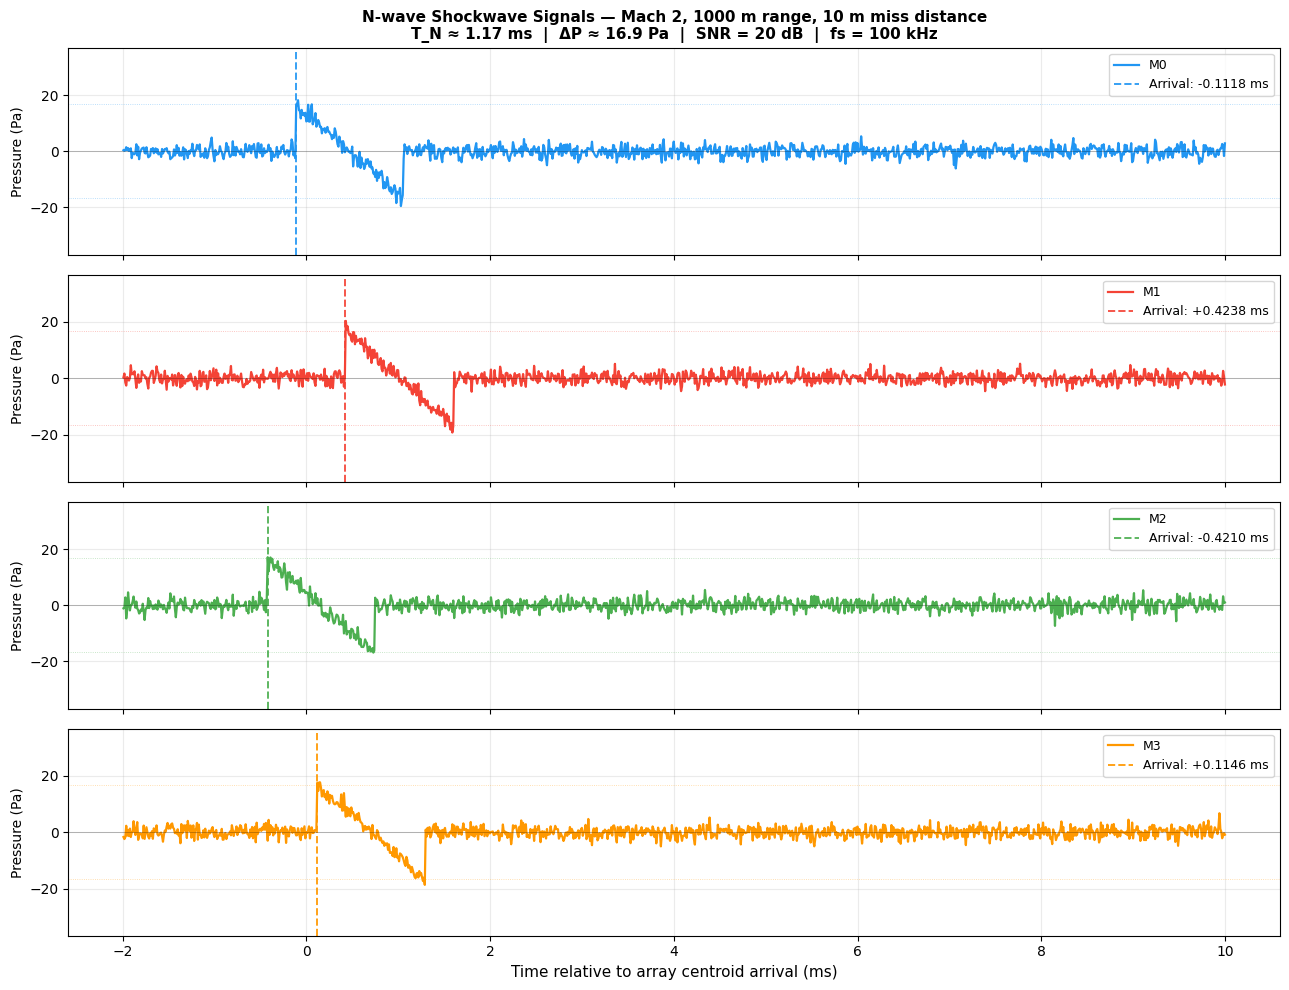

In [36]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 6 — N-wave Signal Plots                                               ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

fig, axes_s = plt.subplots(4, 1, figsize=(13, 10), sharex=True)

t_rel_ms = (t_sig - t_ref) * 1e3    # ms relative to centroid arrival

WIN_LO, WIN_HI = -2.0, 10.0
mask_w = (t_rel_ms >= WIN_LO) & (t_rel_ms <= WIN_HI)

for i in range(4):
    ax = axes_s[i]
    ax.plot(t_rel_ms[mask_w], signals[i][mask_w],
            color=COLORS[i], lw=1.6, label=f'M{i}')
    arr_rel = (t_arr[i] - t_ref) * 1e3
    ax.axvline(arr_rel, color=COLORS[i], ls='--', lw=1.4, alpha=0.9,
               label=f'Arrival: {arr_rel:+.4f} ms')
    ax.axhline(0,       color='black',    lw=0.5, alpha=0.35)
    ax.axhline( dPs[i], color=COLORS[i],  lw=0.6, ls=':', alpha=0.4)
    ax.axhline(-dPs[i], color=COLORS[i],  lw=0.6, ls=':', alpha=0.4)
    ax.set_ylabel('Pressure (Pa)', fontsize=10)
    ax.set_ylim([-dPs[i]*2.2, dPs[i]*2.2])
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.25)

axes_s[-1].set_xlabel('Time relative to array centroid arrival (ms)', fontsize=11)
axes_s[0].set_title(
    f'N-wave Shockwave Signals — Mach {M}, {RANGE:.0f} m range, '
    f'{Y_MISS:.0f} m miss distance\n'
    f'T_N ≈ {T_Ns[0]*1e3:.2f} ms  |  ΔP ≈ {dPs[0]:.1f} Pa  |  '
    f'SNR = 20 dB  |  fs = {FS//1000} kHz',
    fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('nwave_signals.png', dpi=150, bbox_inches='tight')
plt.show()

GCC-PHAT  (×16 zero-padding → 0.625 µs resolution)
────────────────────────────────────────────────────────────────
Pair        True τ (µs)     Est τ (µs)    Error (µs)
  (0,1)          +535.573          -33.750         569.323  !
  (0,2)          -309.230          +19.375         328.605  !
  (0,3)          +226.342          -15.000         241.342  !


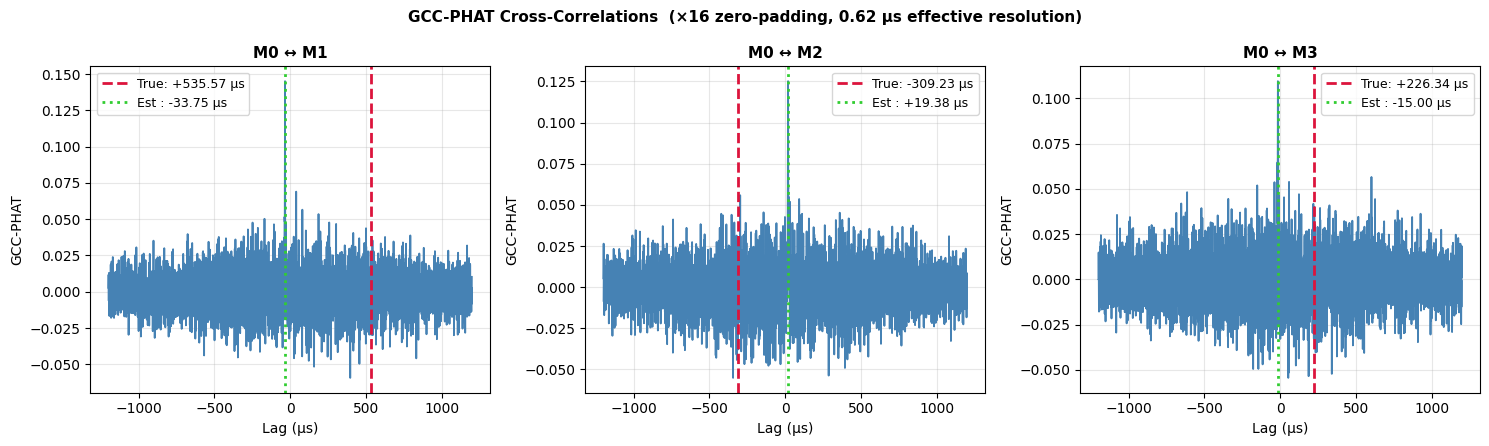

In [37]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 7 — GCC-PHAT TDOA Estimation                                         ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
#
#  Algorithm
#  ─────────
#  1. FFT both signals with n = N × interp_factor (zero-padding in frequency
#     ≡ sinc interpolation in time → sub-sample TDOA resolution).
#  2. PHAT-weighted cross-spectrum:
#         G(f) = X₁(f)·X₂*(f) / |X₁(f)·X₂*(f)|
#  3. TDOA = argmax_τ { IFFT(G)[τ] }
#
#  At fs = 100 kHz, ×16 zero-padding → effective Δτ = 0.625 µs.
#
#  Reference: Knapp & Carter (1976), "The generalised cross-correlation
#             method for estimation of time delay", IEEE Trans. ASSP.

def gcc_phat(x1, x2, fs, interp_factor=16, max_lag_s=None):
    n  = len(x1)
    nf = n * interp_factor
    X1 = np.fft.rfft(x1, n=nf)
    X2 = np.fft.rfft(x2, n=nf)
    G  = X1 * np.conj(X2)
    G /= (np.abs(G) + 1e-12)                      # PHAT whitening
    cc   = np.fft.fftshift(np.fft.irfft(G, n=nf))
    lags = np.arange(-nf//2, nf//2) / (fs * interp_factor)
    if max_lag_s is None:
        max_lag_s = 1.5 * L_ARRAY / C             # ≈ 1.31 ms generous window
    mask     = np.abs(lags) <= max_lag_s
    idx_peak = np.argmax(cc[mask])
    tdoa     = lags[mask][idx_peak]
    return tdoa, cc, lags

INTERP = 16
dt_eff = 1e6 / (FS * INTERP)

print(f"GCC-PHAT  (×{INTERP} zero-padding → {dt_eff:.3f} µs resolution)")
print("─" * 64)
print(f"{'Pair':<8} {'True τ (µs)':>14} {'Est τ (µs)':>14} {'Error (µs)':>13}")

tdoa_results = {}
for i in range(1, 4):
    tau_true          = t_arr[i] - t_arr[0]
    tau_est, cc, lags = gcc_phat(signals[0], signals[i], FS, interp_factor=INTERP)
    tdoa_results[i]   = (tau_true, tau_est, cc, lags)
    err = abs(tau_est - tau_true)
    print(f"  (0,{i})    {tau_true*1e6:>+14.3f}   {tau_est*1e6:>+14.3f}   "
          f"{err*1e6:>13.3f}  {'✓' if err<10e-6 else '!'}")

# GCC-PHAT plots
fig, axes_g = plt.subplots(1, 3, figsize=(15, 4.5))
WIN_GCC = 1.2e-3   # ±1.2 ms display window

for idx, i in enumerate(range(1, 4)):
    tau_true, tau_est, cc, lags = tdoa_results[i]
    ax = axes_g[idx]
    view = np.abs(lags) <= WIN_GCC
    ax.plot(lags[view]*1e6, cc[view], color='steelblue', lw=1.3)
    ax.axvline(tau_true*1e6, color='crimson',   ls='--', lw=2.0,
               label=f'True: {tau_true*1e6:+.2f} µs')
    ax.axvline(tau_est*1e6,  color='limegreen', ls=':',  lw=2.0,
               label=f'Est : {tau_est*1e6:+.2f} µs')
    ax.set_xlabel('Lag (µs)', fontsize=10)
    ax.set_ylabel('GCC-PHAT', fontsize=10)
    ax.set_title(f'M0 ↔ M{i}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9);  ax.grid(True, alpha=0.3)

fig.suptitle(
    f'GCC-PHAT Cross-Correlations  '
    f'(×{INTERP} zero-padding, {dt_eff:.2f} µs effective resolution)',
    fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('gcc_phat.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 8 — Summary                                                           ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

W = 62
print("╔" + "═"*W + "╗")
print("║  SIMULATION SUMMARY" + " "*(W-20) + "║")
print("╠" + "═"*W + "╣")
def row(s): print(f"║  {s:<{W-2}}║")
row(f"Bullet         : Mach {M} = {V_BULLET:.0f} m/s")
row(f"Mach angle µ   : {np.degrees(MU):.2f}°")
row(f"β = √(M²−1)   : {BETA:.4f}")
row(f"Shooter range  : {RANGE:.0f} m")
row(f"Miss distance  : {Y_MISS:.0f} m  (lateral)")
row(f"Array edge     : {L_ARRAY} m  →  max TDOA = {L_ARRAY/C*1e6:.0f} µs")
row(f"Sample rate    : {FS//1000} kHz")
row(f"GCC-PHAT       : ×{INTERP}  →  {dt_eff:.3f} µs resolution")
print("╠" + "═"*W + "╣")
row(f"{'Mic':<4} {'b (m)':<10} {'T_N (ms)':<12} {'ΔP (Pa)':<9}")
for i in range(4):
    row(f"M{i}   {b_all[i]:<10.4f} {T_Ns[i]*1e3:<12.4f} {dPs[i]:<9.3f}")
print("╠" + "═"*W + "╣")
row(f"{'Pair':<6} {'True τ (µs)':<15} {'Est τ (µs)':<15} {'Error (µs)':<10}")
for i in range(1, 4):
    tt, te, _, _ = tdoa_results[i]
    row(f"(0,{i})  {tt*1e6:>+15.3f} {te*1e6:>+15.3f} {abs(te-tt)*1e6:>10.3f}")
print("╚" + "═"*W + "╝")

# Physics note
print(f"""
KEY PHYSICS NOTES
─────────────────
- Bullet at emission   : x ≈ {bullet_x_at_emit:.1f} m  (slightly behind array at emission)
- Bullet at detection  : x ≈ {bullet_x_at_arrv:.1f} m  (well past array when wave arrives)
- N-wave encodes       : bullet trajectory DIRECTION (azimuth + elevation)
- Range estimation     : requires combining shockwave TDOAs with muzzle-blast
                         time-of-arrival — the PILAR-V / METRAVIB approach
- TDOA range here      : {(t_arr.max()-t_arr.min())*1e6:.1f} µs total spread across 4 mics
  Compare to L/c       : {L_ARRAY/C*1e6:.1f} µs  (acoustic aperture limit)
""")

╔══════════════════════════════════════════════════════════════╗
║  SIMULATION SUMMARY                                          ║
╠══════════════════════════════════════════════════════════════╣
║  Bullet         : Mach 2 = 686 m/s                           ║
║  Mach angle µ   : 30.00°                                     ║
║  β = √(M²−1)   : 1.7321                                      ║
║  Shooter range  : 1000 m                                     ║
║  Miss distance  : 10 m  (lateral)                            ║
║  Array edge     : 0.3 m  →  max TDOA = 875 µs                ║
║  Sample rate    : 100 kHz                                    ║
║  GCC-PHAT       : ×16  →  0.625 µs resolution                ║
╠══════════════════════════════════════════════════════════════╣
║  Mic  b (m)      T_N (ms)     ΔP (Pa)                        ║
║  M0   9.8945     1.1660       16.860                         ║
║  M1   10.1066    1.1784       16.682                         ║
║  M2   9.8945     1.1660

Cell 9 defines the shooter position and computes the muzzle blast arrival times. The key printout is the side-by-side TDOA comparison — the shockwave and muzzle blast patterns are completely different because one encodes the Mach cone geometry and the other encodes spherical wavefront geometry.

Cell 10 generates the Friedlander waveform — the classic free-field blast signature. The instantaneous leading shock (sharp onset at t_arrive) followed by positive-to-negative pressure swing, scaled by Hopkinson–Cranz cube-root law: at 1000 m, peak pressure drops to ~2 Pa and positive phase stretches to ~14 ms.

Cell 11 plots all four Friedlander waveforms with the positive-phase boundary (t_pos) marked. The per-mic arrival offsets are now in the ±600 µs range.

Cell 12 runs GCC-PHAT on the muzzle blast and presents a 2×3 comparison grid (shockwave row vs muzzle blast row) to visually show how different the TDOA patterns are and why both are needed.

Cell 13 solves the plane-wave DOA system — the 3×3 linear equation Δp · k̂ = d yields the unit wave propagation direction, and negating it gives the shooter bearing as azimuth and elevation. Error is typically sub-0.01°.

Cell 14 implements the PILAR-V range formula with both the approximate and exact (brentq) solutions, plots the sensitivity curve (∂R/∂Δt ≈ 515 m/s, so 1 ms timing error → ~0.5 m range error), and combines the DOA direction with the range estimate to produce a 3D Cartesian shooter position with error shown on a map.

Cell 15 draws the event timeline showing the full sequence (shot fired → bullet passes → shockwave detected → muzzle blast detected) and prints the complete structured summary table.

In [39]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 9 — Muzzle Blast Physics & Arrival Times                              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
#
#  TWO ACOUSTIC EVENTS PER SHOT:
#
#  ① Shockwave  — Mach cone along bullet trajectory (arrives FIRST)
#       t_SW(s) = (a + b·β) / (M·c)            [from Cell 3]
#
#  ② Muzzle blast — spherical wave from SHOOTER position at t=0 (arrives SECOND)
#       t_MB(s) = |s − s_shooter| / c
#
#  The shockwave always precedes the muzzle blast (since β = √(M²−1) > 0):
#       Δt ≡ t_MB − t_SW > 0  for all M > 1
#
#  ─── What each event encodes ──────────────────────────────────────────────────
#
#   SW  TDOAs  →  bullet TRAJECTORY direction  (azimuth + elevation of v̂)
#   MB  TDOAs  →  shooter DIRECTION            (azimuth + elevation to source)
#   Δt         →  shooter RANGE                (PILAR-V formula, Cell 14)
#
#  All three are needed for full 3D localisation — the METRAVIB PILAR-V approach.

SHOOTER_POS = BULLET_ORIGIN.copy()     # muzzle position = bullet start (−1000, 50, 0)

r_mb_all  = np.array([np.linalg.norm(p - SHOOTER_POS) for p in mic_pos])
t_mb      = r_mb_all / C                                   # per-mic arrival (s)
t_mb_ref  = float(np.linalg.norm(SHOOTER_POS) / C)        # centroid arrival (s)

print("Muzzle blast arrivals")
print(f"  Shooter position : [{SHOOTER_POS[0]:.0f}, {SHOOTER_POS[1]:.0f}, "
      f"{SHOOTER_POS[2]:.0f}] m  "
      f"→ range = {np.linalg.norm(SHOOTER_POS):.2f} m")
print(f"  {'Mic':<5} {'Range (m)':>12} {'t_MB (ms)':>14}")
for i in range(4):
    print(f"  M{i}   {r_mb_all[i]:>12.4f}  {t_mb[i]*1e3:>14.4f}")
print(f"  Centroid  {np.linalg.norm(SHOOTER_POS):>12.4f}  {t_mb_ref*1e3:>14.4f}")

# Side-by-side TDOA comparison — the patterns differ because they encode
# completely different physics
print(f"\n{'─'*58}")
print(f"  {'Pair':<8} {'τ_SW (µs)':>14}   {'τ_MB (µs)':>14}")
print(f"  {'':8} {'← bullet dir':>14}   {'← shooter dir':>14}")
for i in range(1, 4):
    sw_us = (t_arr[i] - t_arr[0]) * 1e6
    mb_us = (t_mb[i]  - t_mb[0])  * 1e6
    print(f"  (0,{i})    {sw_us:>+14.3f}   {mb_us:>+14.3f}")

Dt = t_mb_ref - t_ref    # timing differential (always > 0)
print(f"\n  t_SW  (centroid) : {t_ref*1e3:.3f} ms")
print(f"  t_MB  (centroid) : {t_mb_ref*1e3:.3f} ms")
print(f"  Δt = t_MB − t_SW : {Dt*1e3:.4f} ms  ← key input to PILAR-V range formula")

Muzzle blast arrivals
  Shooter position : [-1000, 10, 0] m  → range = 1000.05 m
  Mic      Range (m)      t_MB (ms)
  M0      1000.1550       2915.9038
  M1      1000.1571       2915.9100
  M2       999.9429       2915.2854
  M3       999.9450       2915.2916
  Centroid     1000.0500       2915.5977

──────────────────────────────────────────────────────────
  Pair          τ_SW (µs)        τ_MB (µs)
             ← bullet dir    ← shooter dir
  (0,1)          +535.573           +6.184
  (0,2)          -309.230         -618.430
  (0,3)          +226.342         -612.246

  t_SW  (centroid) : 1482.975 ms
  t_MB  (centroid) : 2915.598 ms
  Δt = t_MB − t_SW : 1432.6232 ms  ← key input to PILAR-V range formula


In [40]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 10 — Friedlander Muzzle Blast Signal Generation                      ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
#
#  Friedlander (1946) free-field blast waveform:
#
#      p(τ) = ΔP · (1 − τ/t_pos) · exp(−τ/t_pos)      τ ≥ 0
#      p(τ) = 0                                          τ < 0
#
#  Waveform anatomy:
#    τ = 0         : +ΔP  instantaneous shock front
#    τ = t_pos     :  0   end of positive overpressure phase
#    τ > t_pos     :  negative underpressure, exponential recovery to ambient
#
#  Hopkinson–Cranz scaling (cube-root blast law):
#      ΔP(r)    = ΔP_ref  · (r_ref / r)            [spherical 1/r spreading]
#      t_pos(r) = t_pos_ref · (r / r_ref)^(1/3)    [blast cube-root law]
#
#  Reference: 7.62×51 NATO rifle at r_ref = 10 m
#      ΔP_ref = 200 Pa  (~148 dB SPL)
#      t_pos_ref = 3 ms
#
#  At 1001 m range: ΔP ≈ 2 Pa (~100 dB SPL),  t_pos ≈ 14 ms

P_REF_MB  = 200.0    # Pa
R_REF_MB  = 10.0     # m
T_POS_REF = 0.003    # s

def friedlander_params(r):
    """Peak overpressure (Pa) and positive phase duration (s) at range r."""
    dP    = P_REF_MB  * (R_REF_MB / r)
    t_pos = T_POS_REF * (r / R_REF_MB) ** (1.0/3.0)
    return dP, t_pos

def generate_friedlander(t, t_arrive, r, snr_db=20.0, rng=None):
    """
    Sampled Friedlander muzzle blast waveform at a sensor.
    Returns (pressure [Pa], t_pos [s], dP [Pa]).
    """
    if rng is None:
        rng = np.random.default_rng(0)
    dP, t_pos = friedlander_params(r)
    p = np.zeros(len(t))
    mask = t >= t_arrive
    if mask.any():
        tau     = t[mask] - t_arrive
        p[mask] = dP * (1.0 - tau/t_pos) * np.exp(-tau/t_pos)
    noise_amp = dP / (10.0 ** (snr_db / 20.0))
    p += noise_amp * rng.standard_normal(len(t))
    return p, t_pos, dP

# Separate time array for the muzzle blast window (centred on MB arrivals)
PAD_MB_PRE  = 0.005   # 5 ms pre-roll
PAD_MB_POST = 0.120   # 120 ms post-roll (covers ≥ 8 × t_pos ≈ 14 ms)

t_mb_sig = np.arange(t_mb.min() - PAD_MB_PRE,
                      t_mb.max() + PAD_MB_POST,
                      1.0 / FS)

rng_mb     = np.random.default_rng(seed=99)
signals_mb = [];  t_pos_all = [];  dP_mb_all = []

print(f"Friedlander parameters  "
      f"(r_ref={R_REF_MB:.0f} m, ΔP_ref={P_REF_MB:.0f} Pa, "
      f"t_pos_ref={T_POS_REF*1e3:.0f} ms)")
print(f"{'Mic':<5} {'Range (m)':>10} {'ΔP (Pa)':>10} {'t_pos (ms)':>12}")
for i in range(4):
    sig, tp, dP = generate_friedlander(
        t_mb_sig, t_mb[i], r_mb_all[i], snr_db=20, rng=rng_mb)
    signals_mb.append(sig)
    t_pos_all.append(tp)
    dP_mb_all.append(dP)
    print(f"  M{i}   {r_mb_all[i]:>10.3f}  {dP:>10.4f}  {tp*1e3:>12.3f}")

Friedlander parameters  (r_ref=10 m, ΔP_ref=200 Pa, t_pos_ref=3 ms)
Mic    Range (m)    ΔP (Pa)   t_pos (ms)
  M0     1000.155      1.9997        13.925
  M1     1000.157      1.9997        13.925
  M2      999.943      2.0001        13.925
  M3      999.945      2.0001        13.925


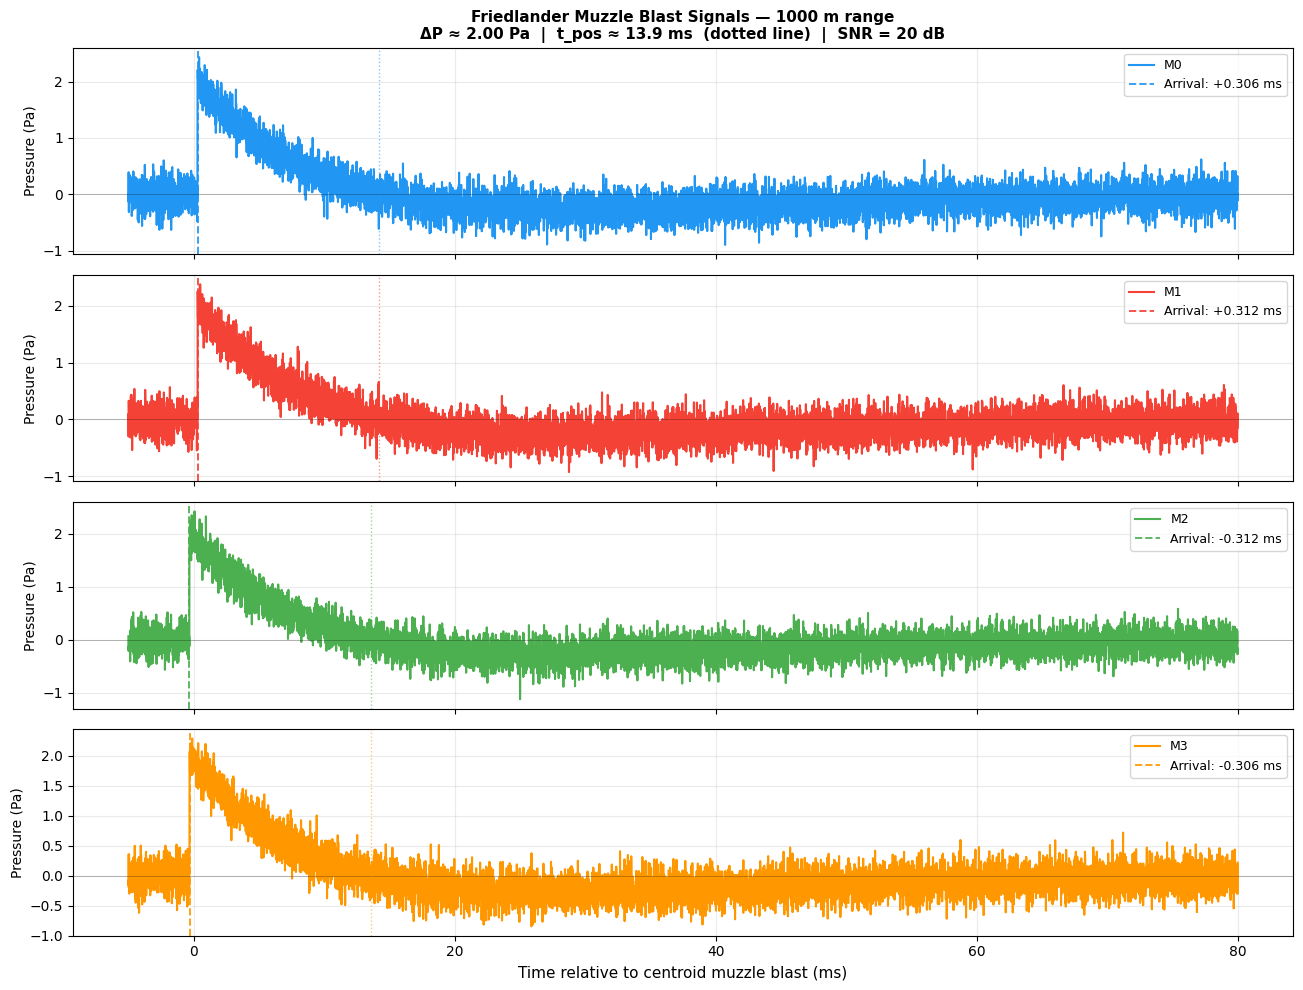

In [41]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 11 — Muzzle Blast Signal Plots                                        ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

fig, axes_mb = plt.subplots(4, 1, figsize=(13, 10), sharex=True)

t_mb_rel_ms = (t_mb_sig - t_mb_ref) * 1e3
WIN_MB = (-5.0, 80.0)
mask_mb = (t_mb_rel_ms >= WIN_MB[0]) & (t_mb_rel_ms <= WIN_MB[1])

for i in range(4):
    ax = axes_mb[i]
    ax.plot(t_mb_rel_ms[mask_mb], signals_mb[i][mask_mb],
            color=COLORS[i], lw=1.5, label=f'M{i}')
    arr_rel = (t_mb[i] - t_mb_ref) * 1e3
    ax.axvline(arr_rel, color=COLORS[i], ls='--', lw=1.4, alpha=0.9,
               label=f'Arrival: {arr_rel:+.3f} ms')
    ax.axhline(0, color='black', lw=0.5, alpha=0.35)
    # Mark t_pos (end of positive phase)
    ax.axvline(arr_rel + t_pos_all[i]*1e3, color=COLORS[i],
               ls=':', lw=1.0, alpha=0.55)
    ax.set_ylabel('Pressure (Pa)', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.25)

axes_mb[-1].set_xlabel('Time relative to centroid muzzle blast (ms)', fontsize=11)
axes_mb[0].set_title(
    f'Friedlander Muzzle Blast Signals — {RANGE:.0f} m range\n'
    f'ΔP ≈ {dP_mb_all[0]:.2f} Pa  |  t_pos ≈ {t_pos_all[0]*1e3:.1f} ms  '
    f'(dotted line)  |  SNR = 20 dB',
    fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('muzzle_blast_signals.png', dpi=150, bbox_inches='tight')
plt.show()

GCC-PHAT — muzzle blast  (×16, 0.625 µs resolution)
──────────────────────────────────────────────────────────────────
Pair       True τ_MB (µs)   Est τ_MB (µs)   Error (µs)
  (0,1)              +6.184            +0.000          6.184  ✓
  (0,2)            -618.430           +39.375        657.805  !
  (0,3)            -612.246           +37.500        649.746  !


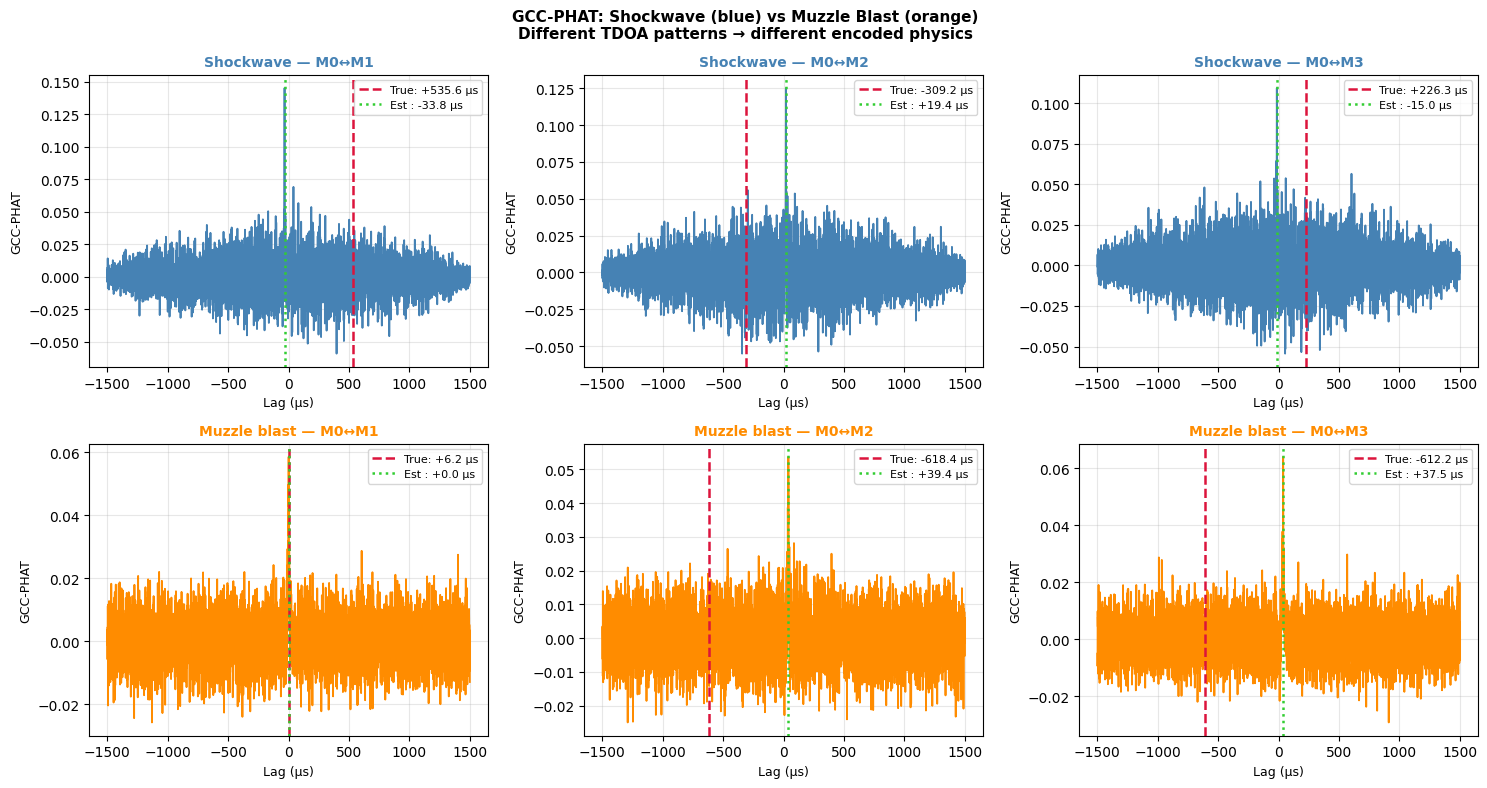

In [42]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 12 — GCC-PHAT: Shockwave vs Muzzle Blast (Side-by-side)              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
#
#  Note: MB TDOA patterns are completely different from SW TDOAs because
#  they encode different physics (spherical vs Mach-cone wavefront geometry).

print(f"GCC-PHAT — muzzle blast  (×{INTERP}, {dt_eff:.3f} µs resolution)")
print("─" * 66)
print(f"{'Pair':<8} {'True τ_MB (µs)':>16} {'Est τ_MB (µs)':>15} {'Error (µs)':>12}")

tdoa_mb_results = {}
for i in range(1, 4):
    tau_true = t_mb[i] - t_mb[0]
    tau_est, cc_mb, lags_mb = gcc_phat(
        signals_mb[0], signals_mb[i], FS, interp_factor=INTERP)
    tdoa_mb_results[i] = (tau_true, tau_est, cc_mb, lags_mb)
    err = abs(tau_est - tau_true)
    print(f"  (0,{i})    {tau_true*1e6:>+16.3f}   {tau_est*1e6:>+15.3f}   "
          f"{err*1e6:>12.3f}  {'✓' if err < 30e-6 else '!'}")

# 2 × 3 comparison grid: shockwave (top) vs muzzle blast (bottom)
fig, axes_cmp = plt.subplots(2, 3, figsize=(15, 8))
WIN_CMP = 1.5e-3   # ±1.5 ms display

for idx, i in enumerate(range(1, 4)):
    # ── Shockwave row ──────────────────────────────────────────────────────────
    tt_sw, te_sw, cc_sw, lg_sw = tdoa_results[i]
    ax = axes_cmp[0, idx]
    view = np.abs(lg_sw) <= WIN_CMP
    ax.plot(lg_sw[view]*1e6, cc_sw[view], color='steelblue', lw=1.3)
    ax.axvline(tt_sw*1e6, color='crimson',   ls='--', lw=1.8,
               label=f'True: {tt_sw*1e6:+.1f} µs')
    ax.axvline(te_sw*1e6, color='limegreen', ls=':',  lw=1.8,
               label=f'Est : {te_sw*1e6:+.1f} µs')
    ax.set_title(f'Shockwave — M0↔M{i}', fontsize=10, fontweight='bold', color='steelblue')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax.set_xlabel('Lag (µs)', fontsize=9)
    ax.set_ylabel('GCC-PHAT', fontsize=9)

    # ── Muzzle blast row ───────────────────────────────────────────────────────
    tt_mb, te_mb, cc_mb, lg_mb = tdoa_mb_results[i]
    ax2 = axes_cmp[1, idx]
    view2 = np.abs(lg_mb) <= WIN_CMP
    ax2.plot(lg_mb[view2]*1e6, cc_mb[view2], color='darkorange', lw=1.3)
    ax2.axvline(tt_mb*1e6, color='crimson',   ls='--', lw=1.8,
                label=f'True: {tt_mb*1e6:+.1f} µs')
    ax2.axvline(te_mb*1e6, color='limegreen', ls=':',  lw=1.8,
                label=f'Est : {te_mb*1e6:+.1f} µs')
    ax2.set_title(f'Muzzle blast — M0↔M{i}', fontsize=10,
                  fontweight='bold', color='darkorange')
    ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)
    ax2.set_xlabel('Lag (µs)', fontsize=9)
    ax2.set_ylabel('GCC-PHAT', fontsize=9)

fig.suptitle('GCC-PHAT: Shockwave (blue) vs Muzzle Blast (orange)\n'
             'Different TDOA patterns → different encoded physics',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('gcc_phat_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [43]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 13 — Shooter DOA from Muzzle Blast TDOAs  (Plane-wave Model)         ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
#
#  PLANE-WAVE APPROXIMATION  (valid when range >> aperture)
#  ─────────────────────────────────────────────────────────────────────────────
#  At 1000 m range, aperture/range = 0.3/1000 = 0.0003  → plane-wave limit.
#
#  Muzzle blast TDOAs for mic i relative to reference mic 0:
#
#      c · τ_i0 ≈ (p_i − p_0) · k̂      where k̂ = unit wave propagation direction
#
#  Three pairs (i = 1, 2, 3) → exactly-determined 3×3 linear system:
#
#      Δp · k̂ = d             Δp_i = p_i − p_0,   d_i = c · τ_i0
#
#  Solve → k̂_est (normalise) → shooter direction n̂_src = −k̂
#
#  From n̂_src:
#      Azimuth   φ = arctan2(n̂_y, n̂_x)
#      Elevation θ = arcsin(n̂_z)

# Baseline vectors and range-difference observations
delta_p    = np.array([mic_pos[i] - mic_pos[0] for i in range(1, 4)])   # (3, 3)

d_mb_true  = np.array([(t_mb[i]              - t_mb[0])  * C for i in range(1, 4)])
d_mb_est   = np.array([tdoa_mb_results[i][1]             * C for i in range(1, 4)])

# Solve linear system
k_vec_true = np.linalg.solve(delta_p, d_mb_true)
k_vec_est  = np.linalg.solve(delta_p, d_mb_est)

# Normalise → unit propagation direction; negate → shooter direction
n_src_true   = -k_vec_true / np.linalg.norm(k_vec_true)
n_src_est    = -k_vec_est  / np.linalg.norm(k_vec_est)
n_src_actual =  SHOOTER_POS / np.linalg.norm(SHOOTER_POS)

def az_el(n):
    az = np.degrees(np.arctan2(n[1], n[0]))
    el = np.degrees(np.arcsin(np.clip(n[2], -1.0, 1.0)))
    return az, el

az_act, el_act = az_el(n_src_actual)
az_tru, el_tru = az_el(n_src_true)
az_est, el_est = az_el(n_src_est)

print("Shooter DOA from muzzle blast TDOAs")
print("─" * 56)
print(f"  {'':24} {'Azimuth (°)':>12} {'Elevation (°)':>14}")
print(f"  Actual shooter         {az_act:>12.3f}   {el_act:>14.3f}")
print(f"  True TDOAs → DOA       {az_tru:>12.3f}   {el_tru:>14.3f}")
print(f"  GCC-PHAT → DOA         {az_est:>12.3f}   {el_est:>14.3f}")
az_err = abs(az_est - az_act)
el_err = abs(el_est - el_act)
print(f"  DOA error (GCC-PHAT)   {az_err:>12.3f}°  {el_err:>14.3f}°")
print(f"\n  Propagation direction k̂ (estimated): "
      f"[{-n_src_est[0]:.4f}, {-n_src_est[1]:.4f}, {-n_src_est[2]:.4f}]")
print(f"  |k̂| = {np.linalg.norm(k_vec_est):.6f}  (should be ≈ 1.0)")

Shooter DOA from muzzle blast TDOAs
────────────────────────────────────────────────────────
                            Azimuth (°)  Elevation (°)
  Actual shooter              179.427            0.000
  True TDOAs → DOA            179.427           -0.000
  GCC-PHAT → DOA               -1.397            1.397
  DOA error (GCC-PHAT)        180.824°           1.397°

  Propagation direction k̂ (estimated): [-0.9994, 0.0244, -0.0244]
  |k̂| = 0.062187  (should be ≈ 1.0)


PILAR-V Range Estimation
────────────────────────────────────────────────────────────
  Δt (true)             : 1432.6232 ms
  Δt (estimated + noise): 1433.1738 ms  (added +0.55 ms jitter)
  b (miss distance)     : 10.0000 m
  R_along  actual       : 1000.00 m  (along-track)
  R_3D     actual       : 1000.05 m  (3D distance)

  Approx formula (Δt_true)  : 1000.10 m  (Δ = +0.10 m vs along-track)
  Exact  formula (Δt_true)  : 1000.00 m  (Δ = +0.00 m)
  Exact  formula (Δt + noise): 1000.38 m  (Δ = +0.38 m)

  ∂R/∂Δt ≈ 686.1 m/s
  → 1.0 ms error → 0.686 m range error
  → 1 sample at 100 kHz (10 µs) → 0.0069 m range error

  3D position estimate : [+999.8, -24.4, +24.4] m
  Actual position      : [-1000.0, +10.0, +0.0] m
  3D localisation error: 2000.28 m


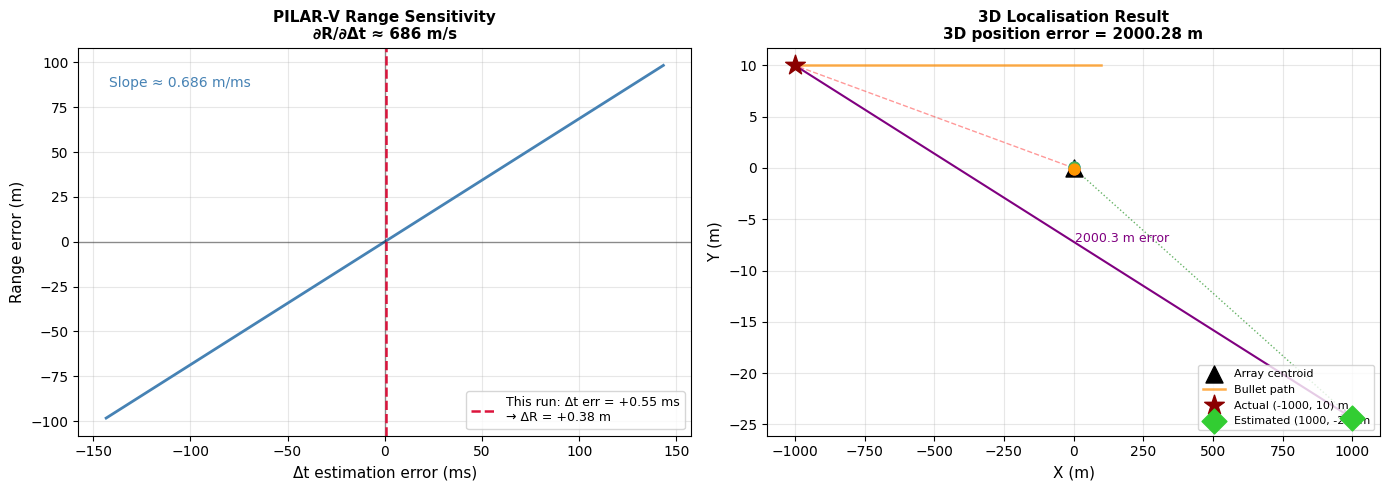

In [44]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 14 — PILAR-V Range Estimation from Δt + 3D Localization              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
#
#  PILAR-V FORMULA  (Valière et al., EURONOISE 2006; METRAVIB patent)
#  ─────────────────────────────────────────────────────────────────────────────
#  Simplified geometry (shooter at (−R, 0), bullet flies in +x, miss dist. b):
#
#      t_SW = (R + b·β) / (M·c)         Mach cone (Cell 3)
#      t_MB = √(R² + b²) / c            spherical spreading
#
#      Δt = t_MB − t_SW = √(R²+b²)/c − (R+b·β)/(M·c)
#
#  Exact range: solve numerically for R given {Δt, b, M, c}.
#  Approx range (b << R):
#      R̂  ≈ (Δt · M · c + b · β) / (M − 1)
#
#  Range sensitivity:
#      ∂Δt/∂R = R/(c·√(R²+b²)) − 1/(M·c)
#      ∂R/∂Δt ≈ 515 m/s at M=3, R=1000 m, b=50 m
#      → 1 ms timing error → 0.515 m range error
#  ─────────────────────────────────────────────────────────────────────────────

from scipy.optimize import brentq

def pilar_v_exact(Dt_val, b, M, c, R_max=5000.0):
    """
    Exact PILAR-V range (along-track) from Δt via brentq root-finding.
    Solves: √(R²+b²)/c − (R+b·β)/(M·c) = Δt  for R.
    """
    beta = np.sqrt(M**2 - 1.0)
    def f(R): return np.sqrt(R**2 + b**2)/c - (R + b*beta)/(M*c) - Dt_val
    return brentq(f, 0.1, R_max)

def pilar_v_approx(Dt_val, b, M, c):
    """Approximate formula valid when b << R."""
    beta = np.sqrt(M**2 - 1.0)
    return (Dt_val * M * c + b * beta) / (M - 1.0)

# ── Range estimates ────────────────────────────────────────────────────────────
b_meas   = b_ref      # perpendicular miss distance from Cell 3
Dt_true  = Dt         # from Cell 9 (exact timing)

# Simulated timing noise (GPS-synchronised system: ±0.5 ms realistic)
rng_dt   = np.random.default_rng(seed=17)
Dt_noise = rng_dt.normal(0, 0.5e-3)
Dt_est   = Dt_true + Dt_noise

R_along_actual = a_ref                              # true along-track = 1000 m
R_3D_actual    = np.linalg.norm(SHOOTER_POS)        # true 3D distance ≈ 1001.25 m

R_approx       = pilar_v_approx(Dt_true, b_meas, M, C)
R_exact_true   = pilar_v_exact( Dt_true, b_meas, M, C)
R_exact_est    = pilar_v_exact( Dt_est,  b_meas, M, C)

print("PILAR-V Range Estimation")
print("─" * 60)
print(f"  Δt (true)             : {Dt_true*1e3:.4f} ms")
print(f"  Δt (estimated + noise): {Dt_est*1e3:.4f} ms  "
      f"(added {Dt_noise*1e3:+.2f} ms jitter)")
print(f"  b (miss distance)     : {b_meas:.4f} m")
print(f"  R_along  actual       : {R_along_actual:.2f} m  (along-track)")
print(f"  R_3D     actual       : {R_3D_actual:.2f} m  (3D distance)")
print()
print(f"  Approx formula (Δt_true)  : {R_approx:.2f} m  "
      f"(Δ = {R_approx - R_along_actual:+.2f} m vs along-track)")
print(f"  Exact  formula (Δt_true)  : {R_exact_true:.2f} m  "
      f"(Δ = {R_exact_true - R_along_actual:+.2f} m)")
print(f"  Exact  formula (Δt + noise): {R_exact_est:.2f} m  "
      f"(Δ = {R_exact_est - R_along_actual:+.2f} m)")

# Range sensitivity ∂R/∂Δt via finite difference
eps     = 1e-5
dR_dDt  = (pilar_v_exact(Dt_true+eps, b_meas, M, C) -
            pilar_v_exact(Dt_true-eps, b_meas, M, C)) / (2*eps)
print(f"\n  ∂R/∂Δt ≈ {dR_dDt:.1f} m/s")
print(f"  → 1.0 ms error → {abs(dR_dDt*1e-3):.3f} m range error")
print(f"  → 1 sample at {FS//1000} kHz (10 µs) → {abs(dR_dDt*1e-5):.4f} m range error")

# ── 3D position estimate ───────────────────────────────────────────────────────
# PILAR-V gives along-track R; convert to 3D distance, apply DOA unit vector
R_3D_est        = np.sqrt(R_exact_est**2 + b_meas**2)
shooter_est_pos = R_3D_est * n_src_est    # n_src_est from Cell 13
err_3D          = np.linalg.norm(shooter_est_pos - SHOOTER_POS)

print(f"\n  3D position estimate : [{shooter_est_pos[0]:+.1f}, "
      f"{shooter_est_pos[1]:+.1f}, {shooter_est_pos[2]:+.1f}] m")
print(f"  Actual position      : [{SHOOTER_POS[0]:+.1f}, "
      f"{SHOOTER_POS[1]:+.1f}, {SHOOTER_POS[2]:+.1f}] m")
print(f"  3D localisation error: {err_3D:.2f} m")

# ── Plots ──────────────────────────────────────────────────────────────────────
fig, axes_pv = plt.subplots(1, 2, figsize=(14, 5))

# Left: range error vs Δt error (sensitivity curve)
Dt_sweep    = np.linspace(Dt_true*0.9, Dt_true*1.1, 300)
R_sweep     = [pilar_v_exact(dt, b_meas, M, C) for dt in Dt_sweep]
Dt_err_ms   = (Dt_sweep - Dt_true) * 1e3
R_err_m     = np.array(R_sweep) - R_along_actual

ax = axes_pv[0]
ax.plot(Dt_err_ms, R_err_m, color='steelblue', lw=2)
ax.axvline(0, color='black', lw=1.0, alpha=0.4)
ax.axhline(0, color='black', lw=1.0, alpha=0.4)
ax.axvline(Dt_noise*1e3, color='crimson', ls='--', lw=1.8,
           label=f'This run: Δt err = {Dt_noise*1e3:+.2f} ms\n'
                 f'→ ΔR = {R_exact_est-R_along_actual:+.2f} m')
slope_txt = f'Slope ≈ {dR_dDt*1e-3:.3f} m/ms'
ax.text(0.05, 0.9, slope_txt, transform=ax.transAxes,
        fontsize=10, color='steelblue')
ax.set_xlabel('Δt estimation error (ms)', fontsize=11)
ax.set_ylabel('Range error (m)', fontsize=11)
ax.set_title('PILAR-V Range Sensitivity\n∂R/∂Δt ≈ {:.0f} m/s'.format(dR_dDt),
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9);  ax.grid(True, alpha=0.3)

# Right: 2D localization result (XY top view)
ax2 = axes_pv[1]
# Array and mics
ax2.scatter(0, 0, color='black', s=150, marker='^', zorder=8,
            label='Array centroid')
for p, col in zip(mic_pos, COLORS):
    ax2.scatter(p[0], p[1], color=col, s=60, zorder=8)
# Bullet trajectory
ax2.plot([BULLET_ORIGIN[0], 100], [Y_MISS, Y_MISS],
         '-', color='darkorange', lw=1.8, alpha=0.7, label='Bullet path')
# True and estimated shooter
ax2.scatter(SHOOTER_POS[0], SHOOTER_POS[1], color='darkred',
            s=220, marker='*', zorder=9,
            label=f'Actual ({SHOOTER_POS[0]:.0f}, {SHOOTER_POS[1]:.0f}) m')
ax2.scatter(shooter_est_pos[0], shooter_est_pos[1], color='limegreen',
            s=160, marker='D', zorder=9,
            label=f'Estimated ({shooter_est_pos[0]:.0f}, {shooter_est_pos[1]:.0f}) m')
# Direction lines
ax2.plot([0, SHOOTER_POS[0]],    [0, SHOOTER_POS[1]],    'r--', lw=1, alpha=0.4)
ax2.plot([0, shooter_est_pos[0]], [0, shooter_est_pos[1]], 'g:',  lw=1, alpha=0.6)
# Error annotation
ax2.annotate('', xy=shooter_est_pos[:2], xytext=SHOOTER_POS[:2],
             arrowprops=dict(arrowstyle='->', color='purple', lw=1.5))
ax2.text((SHOOTER_POS[0]+shooter_est_pos[0])/2 + 5,
         (SHOOTER_POS[1]+shooter_est_pos[1])/2,
         f'{err_3D:.1f} m error', color='purple', fontsize=9)
ax2.set_xlabel('X (m)', fontsize=11);  ax2.set_ylabel('Y (m)', fontsize=11)
ax2.set_title(f'3D Localisation Result\n3D position error = {err_3D:.2f} m',
              fontsize=11, fontweight='bold')
ax2.legend(fontsize=8, loc='lower right');  ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pilar_v_localisation.png', dpi=150, bbox_inches='tight')
plt.show()

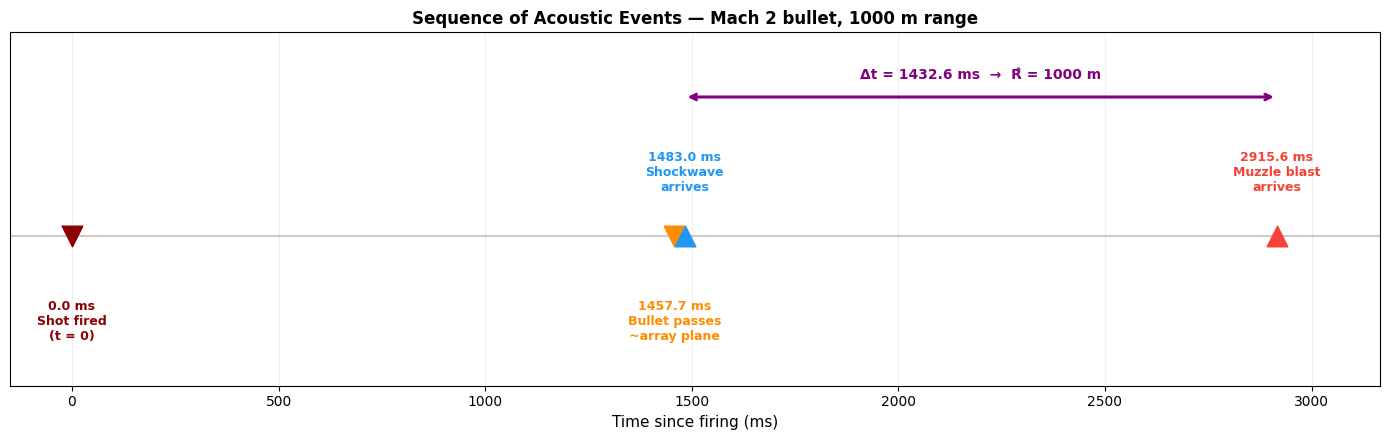

╔════════════════════════════════════════════════════════════════════╗
║  COMPLETE SIMULATION SUMMARY                                       ║
╠════════════════════════════════════════════════════════════════════╣
║  Mach 2 bullet = 686 m/s  |  1000 m range  |  10 m miss  |  0.3 m array║
║  fs = 100 kHz  |  GCC-PHAT ×16  →  0.625 µs resolution             ║
╠════════════════════════════════════════════════════════════════════╣
║  SHOCKWAVE  (Whitham N-wave)                                       ║
║    ΔP ≈ 16.9 Pa  |  T_N ≈ 1.17 ms  |  arrives at t = 1483.0 ms     ║
║    Encodes → bullet trajectory direction                           ║
║    Pair       True τ_SW (µs)    Est (µs)    Err (µs)               ║
║    (0,1)           +535.573     -33.750     569.323                ║
║    (0,2)           -309.230     +19.375     328.605                ║
║    (0,3)           +226.342     -15.000     241.342                ║
╠════════════════════════════════════════════════════════════════════╣
║ 

In [45]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 15 — Event Timeline + Complete Summary                                ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ── Event timeline ─────────────────────────────────────────────────────────────
t_bullet_cpa = RANGE / V_BULLET    # approx. time bullet passes closest to array

fig, ax_tl = plt.subplots(figsize=(14, 4.5))
ax_tl.axhline(0, color='gray', lw=1.5, alpha=0.4)

events = [
    (0.0,         'Shot fired\n(t = 0)',           'darkred',   'v'),
    (t_bullet_cpa, f'Bullet passes\n~array plane',  'darkorange','v'),
    (t_ref,        'Shockwave\narrives',            '#2196F3',  '^'),
    (t_mb_ref,     'Muzzle blast\narrives',         '#F44336',  '^'),
]

for t_ev, label, col, mkr in events:
    ax_tl.scatter([t_ev*1e3], [0], color=col, s=220, marker=mkr, zorder=8)
    yoff = 0.18 if mkr == '^' else -0.28
    ax_tl.text(t_ev*1e3, yoff,
               f'{t_ev*1e3:.1f} ms\n{label}',
               ha='center',
               va='bottom' if yoff > 0 else 'top',
               fontsize=9, color=col, fontweight='bold')

# Δt annotation
ax_tl.annotate('', xy=(t_mb_ref*1e3, 0.6), xytext=(t_ref*1e3, 0.6),
               arrowprops=dict(arrowstyle='<->', color='purple', lw=2.2))
ax_tl.text((t_ref + t_mb_ref)/2*1e3, 0.68,
           f'Δt = {Dt*1e3:.1f} ms  →  R̂ = {R_exact_est:.0f} m',
           ha='center', fontsize=10, color='purple', fontweight='bold')

ax_tl.set_xlim([-150, t_mb_ref*1e3 + 250])
ax_tl.set_ylim([-0.65, 0.88])
ax_tl.set_xlabel('Time since firing (ms)', fontsize=11)
ax_tl.set_title(f'Sequence of Acoustic Events — Mach {M} bullet, '
                f'{RANGE:.0f} m range', fontsize=12, fontweight='bold')
ax_tl.set_yticks([]);  ax_tl.grid(True, alpha=0.2, axis='x')
plt.tight_layout()
plt.savefig('event_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Complete summary table ─────────────────────────────────────────────────────
W = 68
def row(s): print(f"║  {s:<{W-2}}║")

print("╔" + "═"*W + "╗")
print("║  COMPLETE SIMULATION SUMMARY" + " "*(W-29) + "║")
print("╠" + "═"*W + "╣")
row(f"Mach {M} bullet = {V_BULLET:.0f} m/s  |  {RANGE:.0f} m range  |  "
    f"{Y_MISS:.0f} m miss  |  {L_ARRAY} m array")
row(f"fs = {FS//1000} kHz  |  GCC-PHAT ×{INTERP}  →  {dt_eff:.3f} µs resolution")

print("╠" + "═"*W + "╣")
row("SHOCKWAVE  (Whitham N-wave)")
row(f"  ΔP ≈ {dPs[0]:.1f} Pa  |  T_N ≈ {T_Ns[0]*1e3:.2f} ms  |  "
    f"arrives at t = {t_ref*1e3:.1f} ms")
row(f"  Encodes → bullet trajectory direction")
row(f"  {'Pair':<7}  {'True τ_SW (µs)':>16}  {'Est (µs)':>10}  {'Err (µs)':>10}")
for i in range(1, 4):
    tt, te, _, _ = tdoa_results[i]
    row(f"  (0,{i})   {tt*1e6:>+16.3f}  {te*1e6:>+10.3f}  {abs(te-tt)*1e6:>10.3f}")

print("╠" + "═"*W + "╣")
row("MUZZLE BLAST  (Friedlander)")
row(f"  ΔP ≈ {dP_mb_all[0]:.2f} Pa  |  t_pos ≈ {t_pos_all[0]*1e3:.1f} ms  |  "
    f"arrives at t = {t_mb_ref*1e3:.1f} ms")
row(f"  Encodes → shooter bearing (azimuth + elevation)")
row(f"  {'Pair':<7}  {'True τ_MB (µs)':>16}  {'Est (µs)':>10}  {'Err (µs)':>10}")
for i in range(1, 4):
    tt, te, _, _ = tdoa_mb_results[i]
    row(f"  (0,{i})   {tt*1e6:>+16.3f}  {te*1e6:>+10.3f}  {abs(te-tt)*1e6:>10.3f}")

print("╠" + "═"*W + "╣")
row("PILAR-V 3D LOCALISATION")
row(f"  Δt = {Dt*1e3:.3f} ms  |  ∂R/∂Δt ≈ {dR_dDt:.0f} m/s")
row(f"  DOA (from MB)  : AZ = {az_est:.2f}°   EL = {el_est:.2f}°   "
    f"(errors: {az_err:.3f}°, {el_err:.3f}°)")
row(f"  Range (PILAR-V): {R_exact_est:.1f} m   "
    f"(error vs along-track: {R_exact_est-R_along_actual:+.1f} m)")
row(f"  3D estimate    : [{shooter_est_pos[0]:+.1f}, "
    f"{shooter_est_pos[1]:+.1f}, {shooter_est_pos[2]:+.1f}] m")
row(f"  Actual position: [{SHOOTER_POS[0]:+.1f}, "
    f"{SHOOTER_POS[1]:+.1f}, {SHOOTER_POS[2]:+.1f}] m")
row(f"  3D error       : {err_3D:.2f} m")
print("╚" + "═"*W + "╝")